# Notebook 00 — Dataset Preparation
## Saliency Maps for Neural Networks

This notebook downloads **MNIST**, explores it, and saves a clean subset
that Notebook 01 will use for training and visualisation.

**Run this notebook once before opening Notebook 01.**

---

| Step | What happens |
|---|---|
| 1 | Download MNIST via `torchvision` (requires internet, ~11 MB) |
| 2 | Explore class distribution & sample images |
| 3 | Compute pixel statistics needed for normalisation |
| 4 | Save a stratified subset → `mnist_subset.npz` |

> **Why MNIST?** Handwritten digits are simple enough that we can visually judge
> whether a saliency map "makes sense" — a map highlighting the ink strokes of a
> digit is obviously meaningful. This makes MNIST the ideal teaching dataset for
> saliency methods.


## 1. Imports & setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

print(f"PyTorch version  : {torch.__version__}")
print(f"Torchvision      : {torchvision.__version__}")
print(f"NumPy            : {np.__version__}")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

DATA_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")
os.makedirs(DATA_DIR, exist_ok=True)
print(f"\nData will be stored in: {DATA_DIR}")


PyTorch version  : 2.4.0+cpu
Torchvision      : 0.19.0+cpu
NumPy            : 1.26.4

Data will be stored in: /app/notebooks/data


## 2. Download MNIST

`torchvision` fetches MNIST automatically on the first call.
The raw files are ~11 MB and are saved inside the `data/` folder.

> **Offline?** Copy the `data/MNIST/` folder from another machine — the download
> only needs to happen once. After that, `download=False` works.


In [2]:
# Raw download (no normalisation yet — we compute stats below)
raw_transform = transforms.ToTensor()

train_full = torchvision.datasets.MNIST(
    root=DATA_DIR, train=True,  download=True, transform=raw_transform
)
test_full = torchvision.datasets.MNIST(
    root=DATA_DIR, train=False, download=True, transform=raw_transform
)

print(f"Training set : {len(train_full):,} images")
print(f"Test set     : {len(test_full):,} images")
print(f"Image shape  : {train_full[0][0].shape}  (C x H x W)")
print(f"Classes      : {train_full.classes}")


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 9670227.34it/s] 


Extracting /app/notebooks/data/MNIST/raw/train-images-idx3-ubyte.gz to /app/notebooks/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 452999.51it/s]


Extracting /app/notebooks/data/MNIST/raw/train-labels-idx1-ubyte.gz to /app/notebooks/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2308855.85it/s]


Extracting /app/notebooks/data/MNIST/raw/t10k-images-idx3-ubyte.gz to /app/notebooks/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1359489.67it/s]


Extracting /app/notebooks/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /app/notebooks/data/MNIST/raw

Training set : 60,000 images
Test set     : 10,000 images
Image shape  : torch.Size([1, 28, 28])  (C x H x W)
Classes      : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 3. Explore the data

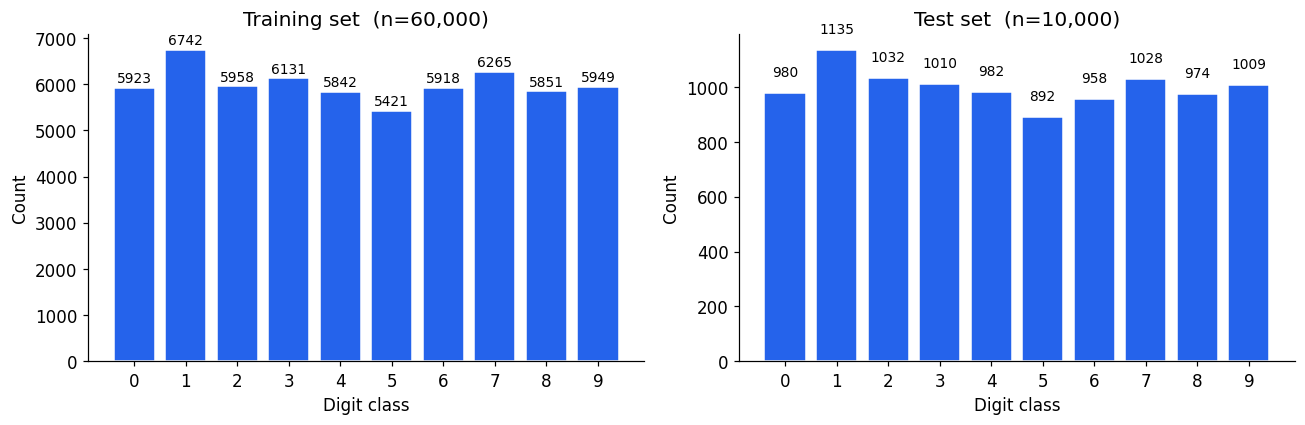

MNIST is well-balanced — each digit has ~6,000 training and ~1,000 test examples.


In [3]:
# ── Class distribution ───────────────────────
train_labels = [train_full[i][1] for i in range(len(train_full))]
test_labels  = [test_full[i][1]  for i in range(len(test_full))]

train_counts = Counter(train_labels)
test_counts  = Counter(test_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in [
    (axes[0], train_counts, f"Training set  (n={len(train_full):,})"),
    (axes[1], test_counts,  f"Test set  (n={len(test_full):,})")
]:
    digits = sorted(counts.keys())
    bars = ax.bar(digits, [counts[d] for d in digits], color="#2563EB", edgecolor="white")
    ax.set(title=title, xlabel="Digit class", ylabel="Count", xticks=digits)
    for bar, d in zip(bars, digits):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(counts[d]), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

print("MNIST is well-balanced — each digit has ~6,000 training and ~1,000 test examples.")


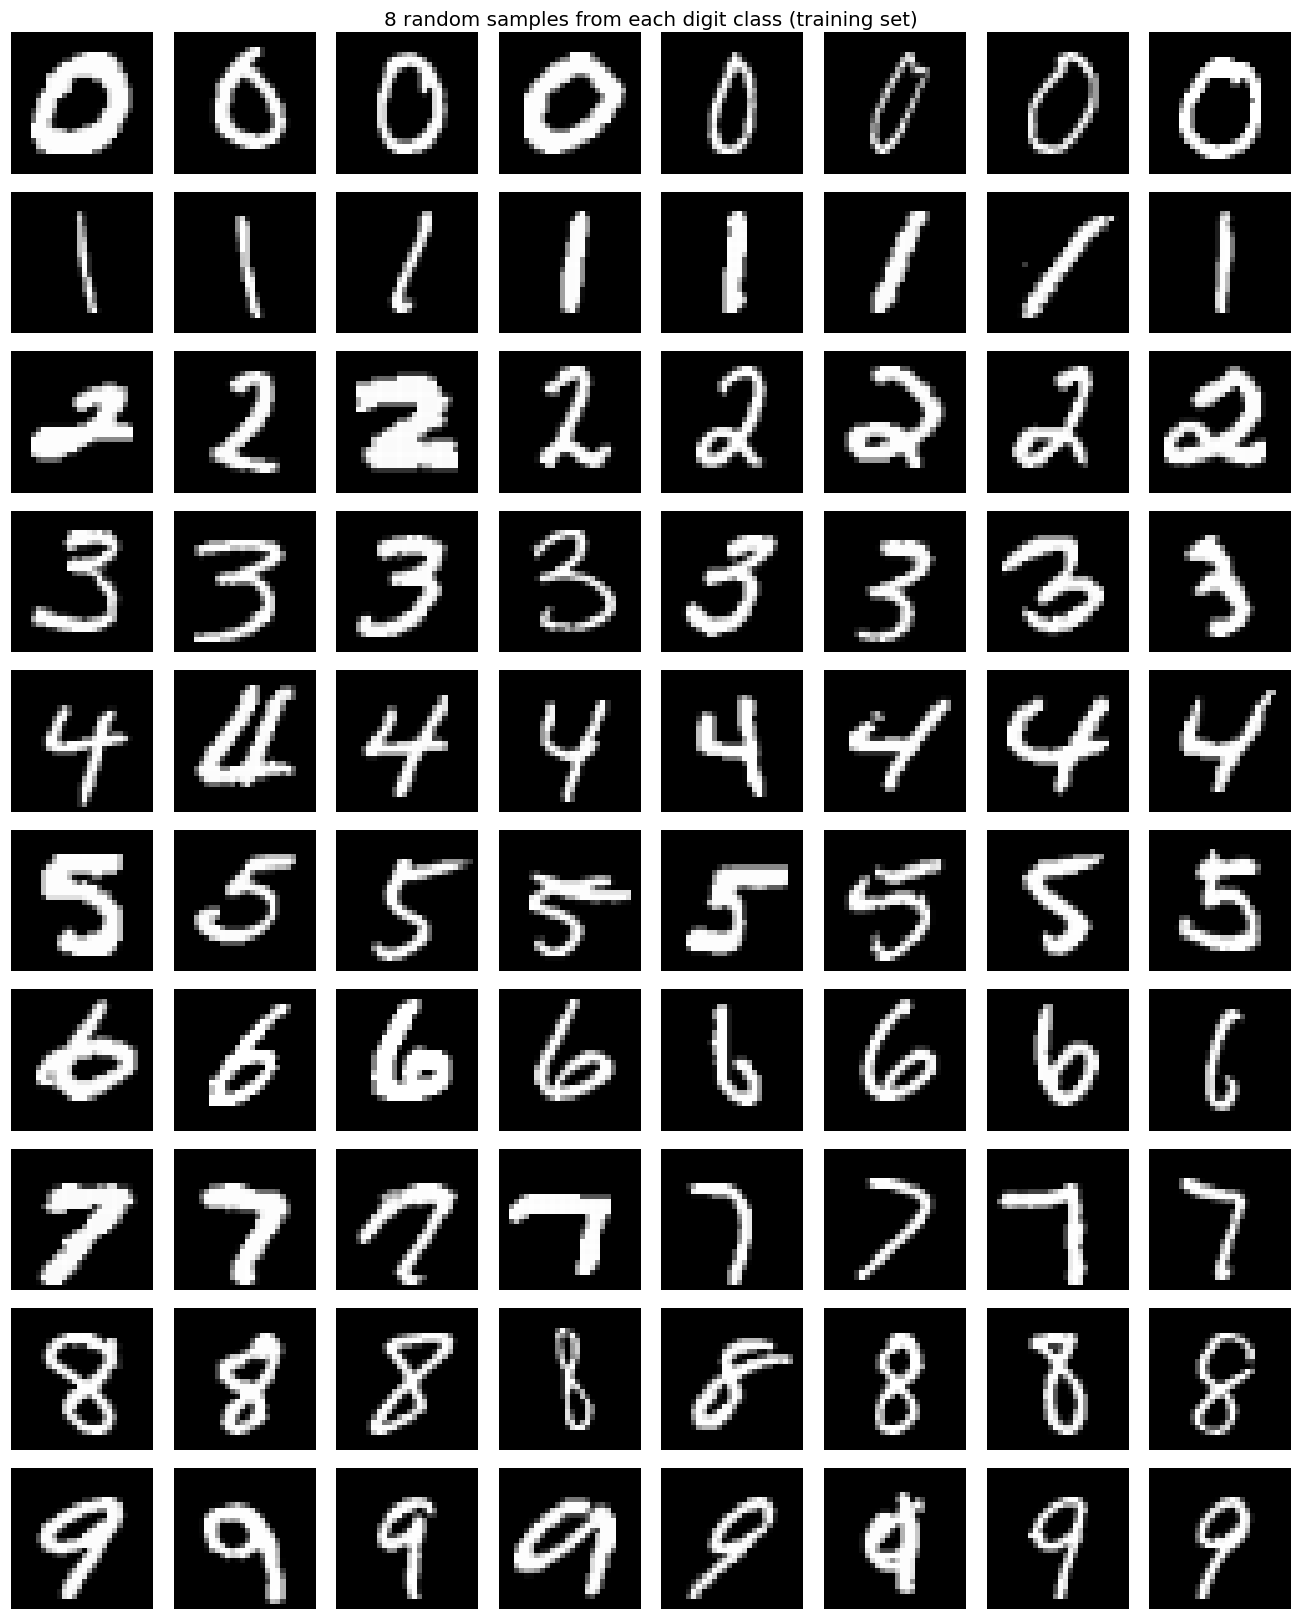

In [4]:
# ── Sample images — one row per digit class ──
fig, axes = plt.subplots(10, 8, figsize=(12, 15))
fig.suptitle("8 random samples from each digit class (training set)", fontsize=13)

# Build index: digit -> list of indices
from collections import defaultdict
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_full):
    class_indices[label].append(idx)

np.random.seed(42)
for digit in range(10):
    chosen = np.random.choice(class_indices[digit], size=8, replace=False)
    for col, idx in enumerate(chosen):
        img, _ = train_full[idx]
        axes[digit][col].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[digit][col].axis("off")
    axes[digit][0].set_ylabel(f"Digit {digit}", fontsize=10, rotation=0,
                              labelpad=35, va="center")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=110, bbox_inches="tight")
plt.show()


## 4. Pixel statistics for normalisation

Neural networks train faster and more stably when inputs are **zero-centred with unit variance**.
We compute the global mean and standard deviation over all training pixels.

These values will be used in the `transforms.Normalize(mean, std)` call in Notebook 01.


In [5]:
loader = DataLoader(train_full, batch_size=1000, shuffle=False, num_workers=0)

pixel_sum   = 0.0
pixel_sum_sq = 0.0
n_pixels = 0

for images, _ in loader:
    pixel_sum    += images.sum().item()
    pixel_sum_sq += (images ** 2).sum().item()
    n_pixels     += images.numel()

mean = pixel_sum / n_pixels
std  = (pixel_sum_sq / n_pixels - mean ** 2) ** 0.5

print("=== MNIST pixel statistics ===")
print(f"  Global mean : {mean:.4f}")
print(f"  Global std  : {std:.4f}")
print()
print("These values are already hard-coded in Notebook 01 as:")
print(f"  transforms.Normalize(mean=({mean:.4f},), std=({std:.4f},))")
print()
print("(For MNIST the standard values 0.1307 / 0.3081 are widely used.)")


=== MNIST pixel statistics ===
  Global mean : 0.1307
  Global std  : 0.3081

These values are already hard-coded in Notebook 01 as:
  transforms.Normalize(mean=(0.1307,), std=(0.3081,))

(For MNIST the standard values 0.1307 / 0.3081 are widely used.)


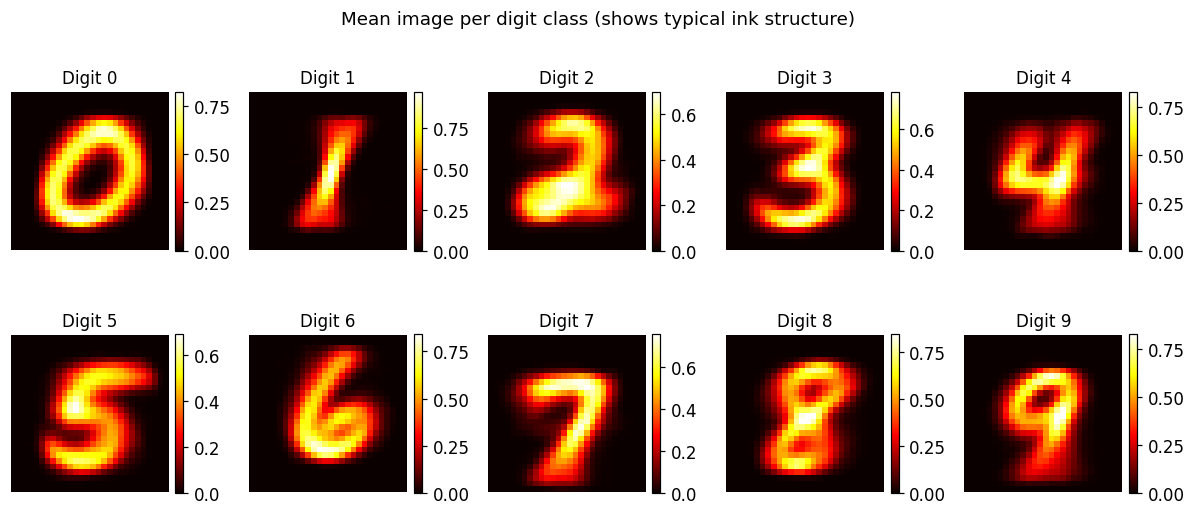

These average images show exactly where ink typically appears for each class.
A good saliency map should highlight similar regions.


In [6]:
# ── Visualise average image per class ─────────
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
fig.suptitle("Mean image per digit class (shows typical ink structure)", fontsize=12)

for digit in range(10):
    idxs = class_indices[digit][:500]   # use first 500
    imgs = torch.stack([train_full[i][0] for i in idxs])
    mean_img = imgs.mean(dim=0).squeeze()
    ax = axes[digit // 5][digit % 5]
    im = ax.imshow(mean_img, cmap="hot", vmin=0, vmax=mean_img.max())
    ax.set_title(f"Digit {digit}", fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("mean_images.png", dpi=110, bbox_inches="tight")
plt.show()
print("These average images show exactly where ink typically appears for each class.")
print("A good saliency map should highlight similar regions.")


## 5. Save a stratified subset

We save a balanced subset of **6,000 training + 1,000 test** images (600 / 100 per class)
as a single `.npz` file. This keeps Notebook 01 fast to load without re-running torchvision.

The images are saved as **raw pixel values** (float32, 0–1 range).
Normalisation happens inside Notebook 01's data loader.


In [7]:
N_TRAIN_PER_CLASS = 600   # 600 × 10 = 6,000 training images
N_TEST_PER_CLASS  = 100   # 100 × 10 = 1,000 test images

np.random.seed(42)

def make_stratified_subset(dataset, n_per_class):
    from collections import defaultdict
    idx_by_class = defaultdict(list)
    for i, (_, label) in enumerate(dataset):
        idx_by_class[label].append(i)

    selected_idx = []
    for cls in range(10):
        chosen = np.random.choice(idx_by_class[cls], size=n_per_class, replace=False)
        selected_idx.extend(chosen.tolist())

    images = np.stack([dataset[i][0].numpy() for i in selected_idx])  # (N, 1, 28, 28)
    labels = np.array([dataset[i][1] for i in selected_idx])
    return images, labels

print("Building training subset...")
X_train, y_train = make_stratified_subset(train_full, N_TRAIN_PER_CLASS)
print("Building test subset...")
X_test,  y_test  = make_stratified_subset(test_full,  N_TEST_PER_CLASS)

OUT_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "mnist_subset.npz")
np.savez_compressed(OUT_PATH,
                    X_train=X_train, y_train=y_train,
                    X_test=X_test,   y_test=y_test)

size_mb = os.path.getsize(OUT_PATH) / 1e6
print(f"\nSaved to: {OUT_PATH}  ({size_mb:.1f} MB)")
print(f"  X_train shape: {X_train.shape}  dtype: {X_train.dtype}")
print(f"  y_train shape: {y_train.shape}  classes: {np.unique(y_train)}")
print(f"  X_test  shape: {X_test.shape}")
print(f"  y_test  shape: {y_test.shape}")


Building training subset...
Building test subset...

Saved to: /app/notebooks/mnist_subset.npz  (1.8 MB)
  X_train shape: (6000, 1, 28, 28)  dtype: float32
  y_train shape: (6000,)  classes: [0 1 2 3 4 5 6 7 8 9]
  X_test  shape: (1000, 1, 28, 28)
  y_test  shape: (1000,)


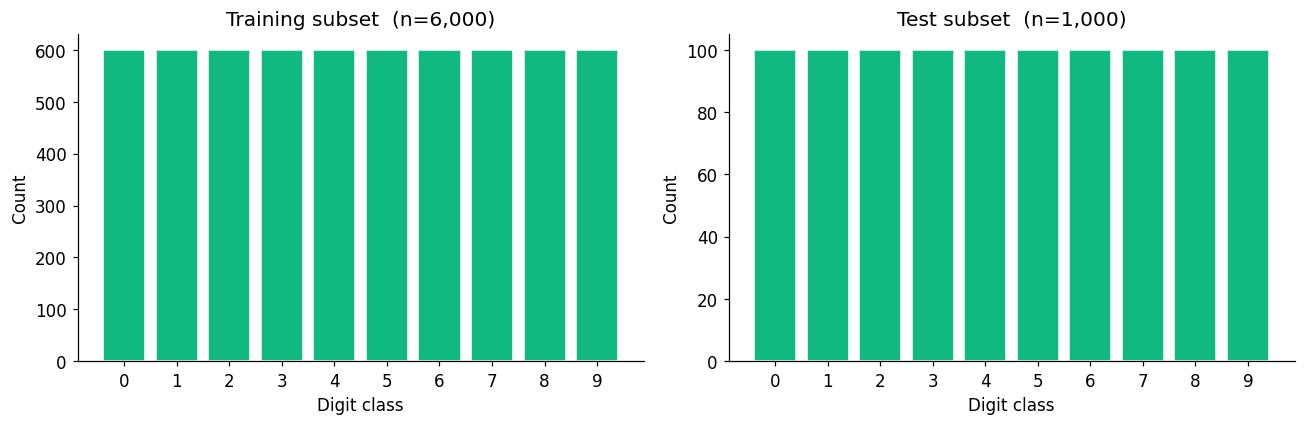

Perfectly balanced — each digit has exactly the same number of examples.


In [8]:
# ── Verify balance ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, labels, title in [
    (axes[0], y_train, f"Training subset  (n={len(y_train):,})"),
    (axes[1], y_test,  f"Test subset  (n={len(y_test):,})")
]:
    counts = Counter(labels)
    ax.bar(sorted(counts), [counts[d] for d in sorted(counts)],
           color="#10B981", edgecolor="white")
    ax.set(title=title, xlabel="Digit class", ylabel="Count",
           xticks=range(10))
plt.tight_layout()
plt.savefig("subset_balance.png", dpi=110, bbox_inches="tight")
plt.show()
print("Perfectly balanced — each digit has exactly the same number of examples.")


## 6. Summary

| What was created | Detail |
|---|---|
| `data/MNIST/` | Raw MNIST files (downloaded by torchvision) |
| `mnist_subset.npz` | 6,000 train + 1,000 test images, balanced across 10 classes |
| Image format | float32, shape `(1, 28, 28)`, pixel values in [0, 1] |
| Normalisation | **Not applied here.** Done inside Notebook 01 |

**You are ready to open Notebook 01.**

---

### A note on MNIST and saliency maps

MNIST is almost "too easy" for modern CNNs — a simple network reaches >99% accuracy.
The saliency maps it produces are reliable and easy to interpret visually.